# Bank Marketing Data Analysis
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

In [1]:

import pandas as pd

# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:

# Check for missing values and data types
print('Shape:', df.shape)
print()
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())


Shape: (41188, 21)

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed 

In [3]:

# Summary statistics
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


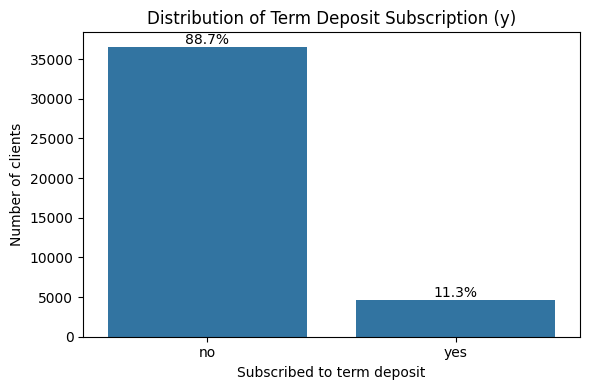

In [4]:

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the target variable
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='y', data=df, order=df['y'].value_counts().index)
plt.title('Distribution of Term Deposit Subscription (y)')
plt.xlabel('Subscribed to term deposit')
plt.ylabel('Number of clients')

total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


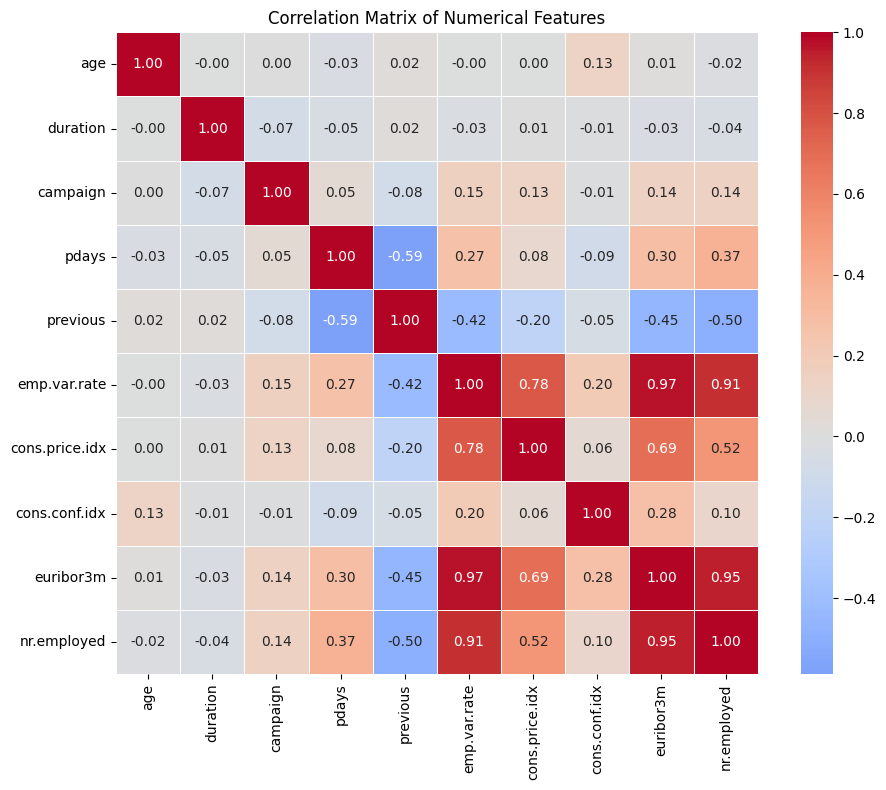

In [5]:

# Correlation matrix for numerical features
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


## Deeper Bivariate EDA
Exploring how subscription rate (`y`) varies across customer segments and campaign attributes.

In [6]:

# Helper to compute subscription rate by a categorical column
def subscription_rate_by(col, order=None):
    rate = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values(ascending=False)
    if order is not None:
        rate = rate.reindex(order)
    return rate


### Subscription rate by job, education, marital status, and contact type

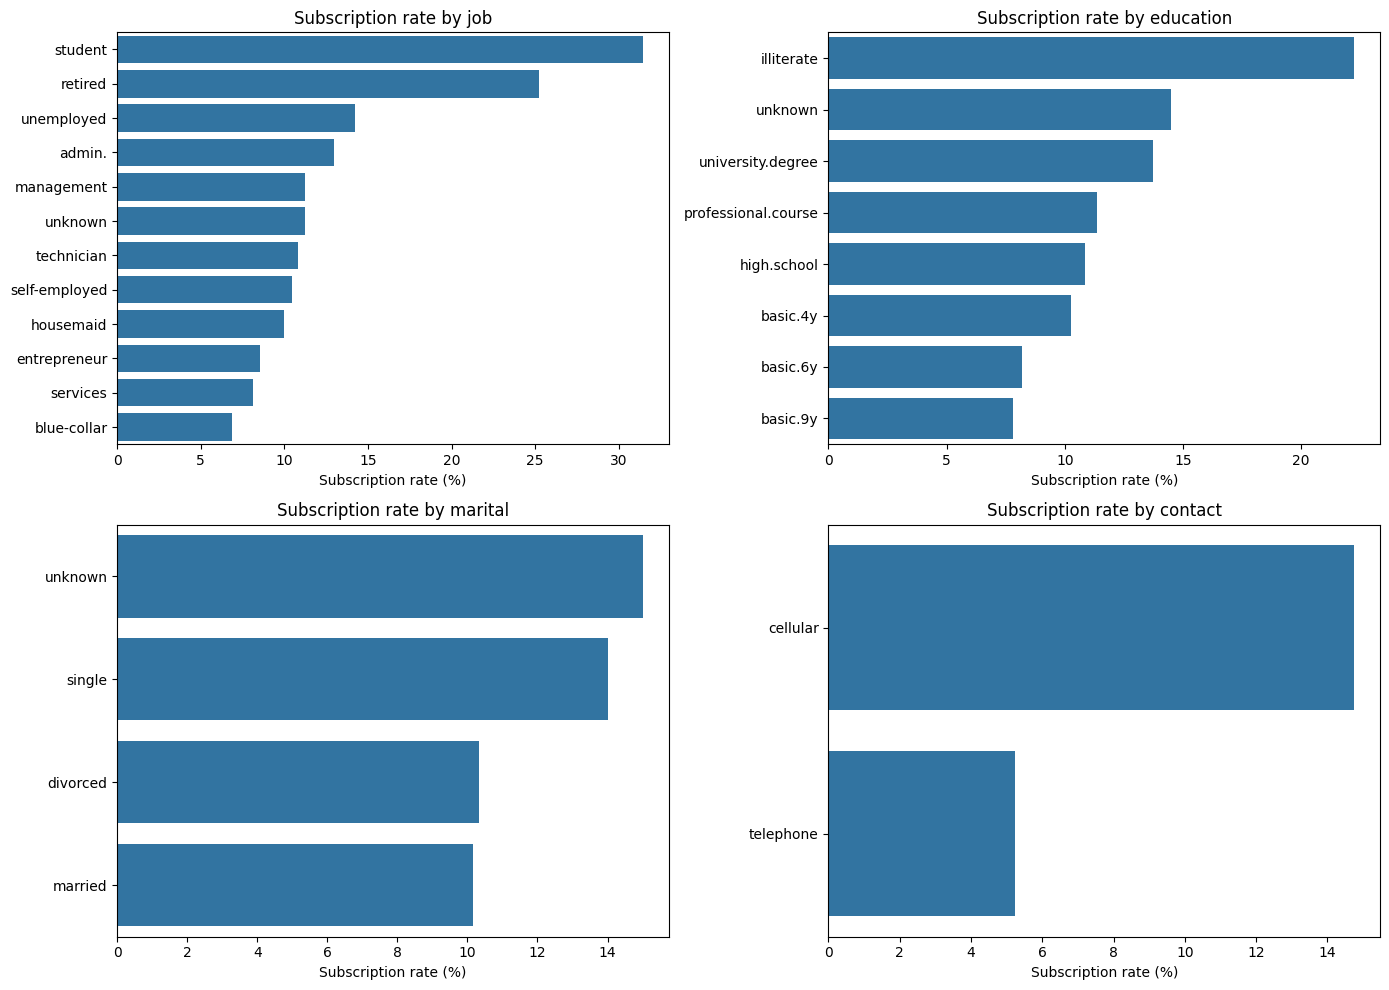

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, ['job', 'education', 'marital', 'contact']):
    rate = subscription_rate_by(col) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, orient='h')
    ax.set_title(f'Subscription rate by {col}')
    ax.set_xlabel('Subscription rate (%)')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


### Subscription rate by month and day of week

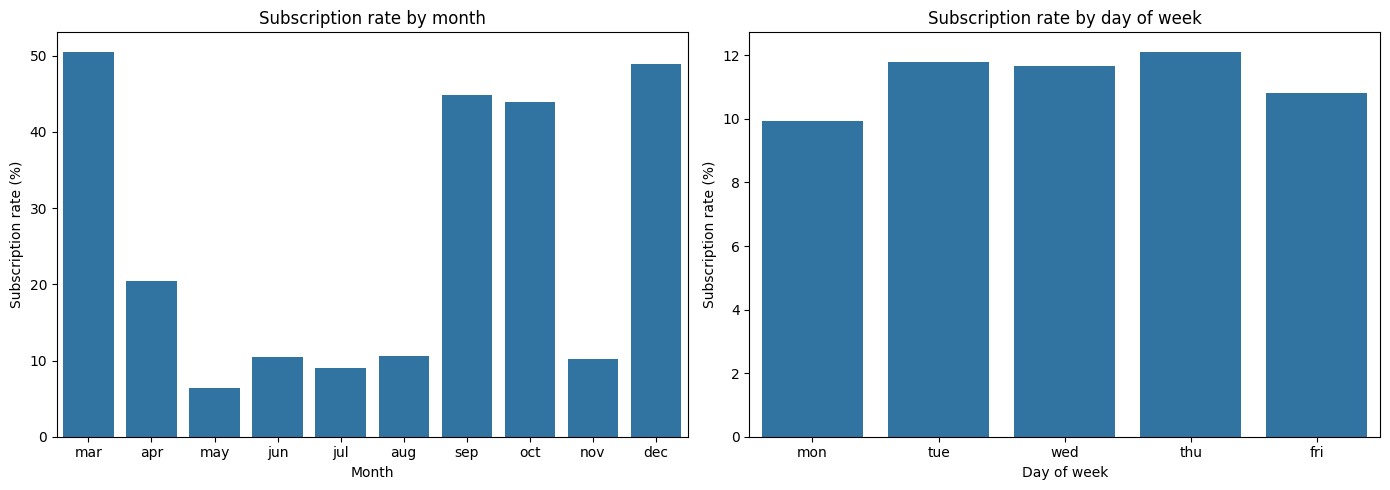

Note: month here reflects last-contact month, not calendar seasonality across years — the
dataset spans a limited multi-year window concentrated heavily in May-August contacts.


In [8]:

month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_rate = subscription_rate_by('month', order=month_order) * 100
sns.barplot(x=month_rate.index, y=month_rate.values, ax=axes[0])
axes[0].set_title('Subscription rate by month')
axes[0].set_ylabel('Subscription rate (%)')
axes[0].set_xlabel('Month')

day_rate = subscription_rate_by('day_of_week', order=day_order) * 100
sns.barplot(x=day_rate.index, y=day_rate.values, ax=axes[1])
axes[1].set_title('Subscription rate by day of week')
axes[1].set_ylabel('Subscription rate (%)')
axes[1].set_xlabel('Day of week')

plt.tight_layout()
plt.show()

print('Note: month here reflects last-contact month, not calendar seasonality across years \u2014 the')
print('dataset spans a limited multi-year window concentrated heavily in May-August contacts.')


### A note on `duration`

The `duration` column (last contact duration, in seconds) is **strongly associated with the outcome**, but it is only known *after* a call ends — a call that never connects has duration 0 and is almost never a 'yes'. Using `duration` to predict `y` **leaks the outcome** and produces an unrealistically strong model that has no practical use for deciding who to call *before* the call happens.

We keep it in this EDA for completeness, but it will be **dropped before predictive modeling** in Phase 2.

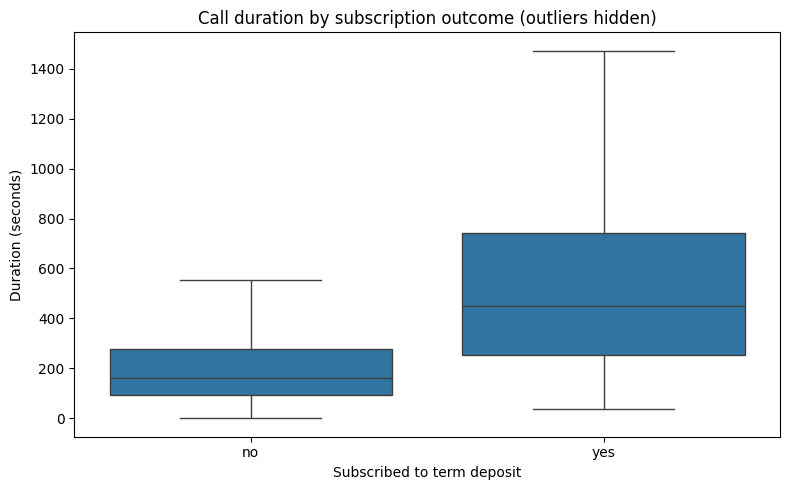

y
no     163.5
yes    449.0
Name: duration, dtype: float64


In [9]:

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='y', y='duration', data=df, ax=ax, showfliers=False)
ax.set_title('Call duration by subscription outcome (outliers hidden)')
ax.set_xlabel('Subscribed to term deposit')
ax.set_ylabel('Duration (seconds)')
plt.tight_layout()
plt.show()

print(df.groupby('y')['duration'].median())


### Subscription rate by age group

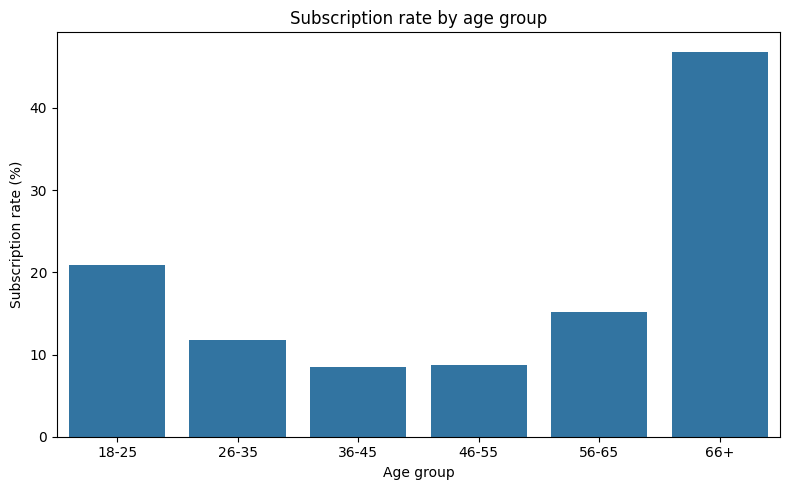

In [10]:

age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

age_rate = subscription_rate_by('age_group', order=age_labels) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=age_rate.index, y=age_rate.values)
plt.title('Subscription rate by age group')
plt.xlabel('Age group')
plt.ylabel('Subscription rate (%)')
plt.tight_layout()
plt.show()


### Campaign contact history: `campaign`, `pdays`, `previous`, `poutcome`

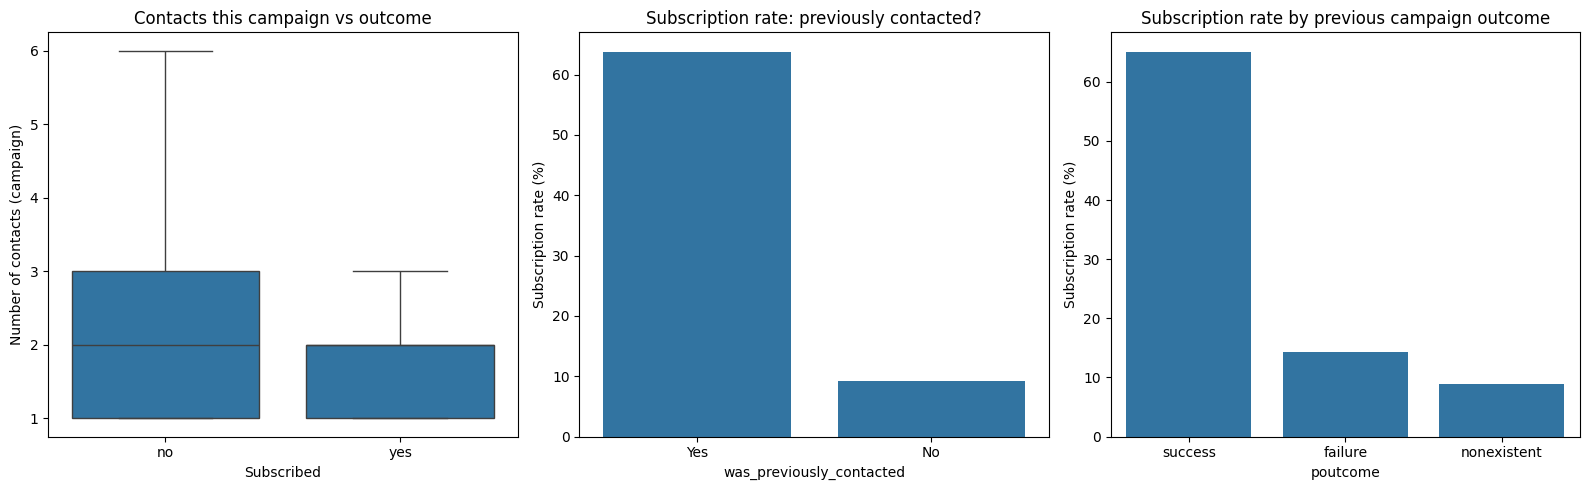

In [11]:

# pdays == 999 means the client was never previously contacted
df['was_previously_contacted'] = df['pdays'] != 999

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Number of contacts during this campaign vs outcome
sns.boxplot(x='y', y='campaign', data=df, ax=axes[0], showfliers=False)
axes[0].set_title('Contacts this campaign vs outcome')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Number of contacts (campaign)')

# Previously contacted vs outcome
contacted_rate = subscription_rate_by('was_previously_contacted') * 100
sns.barplot(x=contacted_rate.index.map({True: 'Yes', False: 'No'}), y=contacted_rate.values, ax=axes[1])
axes[1].set_title('Subscription rate: previously contacted?')
axes[1].set_ylabel('Subscription rate (%)')

# Previous campaign outcome vs current outcome
poutcome_rate = subscription_rate_by('poutcome') * 100
sns.barplot(x=poutcome_rate.index, y=poutcome_rate.values, ax=axes[2])
axes[2].set_title('Subscription rate by previous campaign outcome')
axes[2].set_ylabel('Subscription rate (%)')

plt.tight_layout()
plt.show()


## Phase 2: Predictive Modeling

Goal: predict whether a client will subscribe to a term deposit (`y`) using information available **before** a call is made — so `duration` is excluded (see leakage note above). We also handle the ~89/11 class imbalance and evaluate with precision/recall/F1/ROC-AUC rather than plain accuracy.

### Feature engineering

In [12]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

model_df = df.drop(columns=['duration', 'age_group']).copy()

# pdays == 999 means 'never previously contacted' -- recode as a flag plus a capped numeric value
model_df['was_previously_contacted'] = (model_df['pdays'] != 999).astype(int)
model_df['pdays_capped'] = model_df['pdays'].replace(999, -1)
model_df = model_df.drop(columns=['pdays'])

X = model_df.drop(columns=['y'])
y_target = (model_df['y'] == 'yes').astype(int)

categorical_cols = X.select_dtypes(include='object').columns.tolist() + X.select_dtypes(include='string').columns.tolist()
categorical_cols = list(dict.fromkeys(categorical_cols))
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train positive rate:', y_train.mean().round(3), ' Test positive rate:', y_test.mean().round(3))


Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_previously_contacted', 'pdays_capped']
Train shape: (32950, 20)  Test shape: (8238, 20)
Train positive rate: 0.113  Test positive rate: 0.113


/tmp/ipykernel_559/2979577252.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist() + X.select_dtypes(include='string').columns.tolist()


### Preprocessing pipeline

In [13]:

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
])


### Baseline model: Logistic Regression

Using `class_weight='balanced'` to account for the imbalanced target instead of oversampling, so the model doesn't just learn to always predict 'no'.

In [14]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

logreg_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

logreg_pipe.fit(X_train, y_train)
logreg_preds = logreg_pipe.predict(X_test)
logreg_proba = logreg_pipe.predict_proba(X_test)[:, 1]

print('--- Logistic Regression ---')
print(classification_report(y_test, logreg_preds, target_names=['no', 'yes']))
print('ROC-AUC:', round(roc_auc_score(y_test, logreg_proba), 3))


--- Logistic Regression ---
              precision    recall  f1-score   support

          no       0.95      0.86      0.90      7310
         yes       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238

ROC-AUC: 0.801


### Random Forest

In [15]:

from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
rf_preds = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

print('--- Random Forest ---')
print(classification_report(y_test, rf_preds, target_names=['no', 'yes']))
print('ROC-AUC:', round(roc_auc_score(y_test, rf_proba), 3))


--- Random Forest ---
              precision    recall  f1-score   support

          no       0.95      0.89      0.92      7310
         yes       0.42      0.64      0.51       928

    accuracy                           0.86      8238
   macro avg       0.69      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238

ROC-AUC: 0.814


### Model comparison: confusion matrices and ROC-AUC

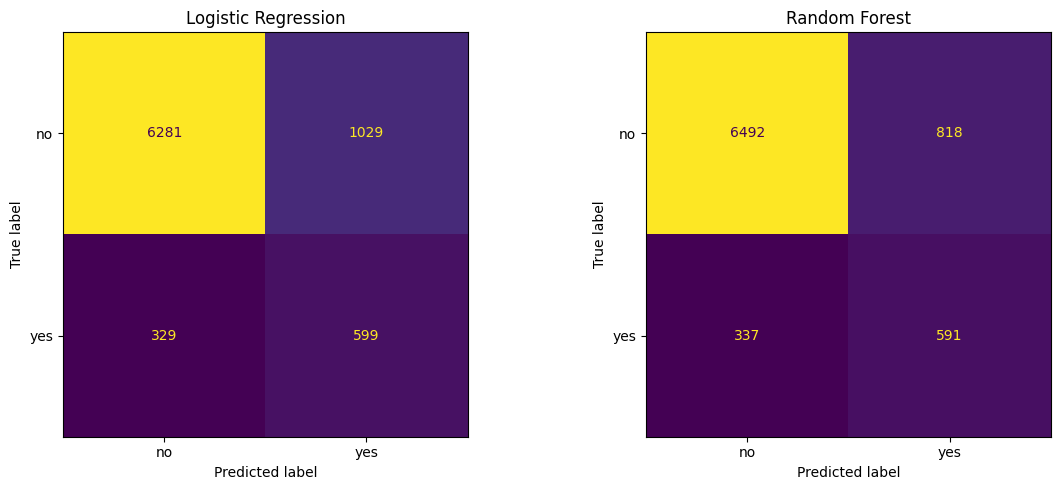

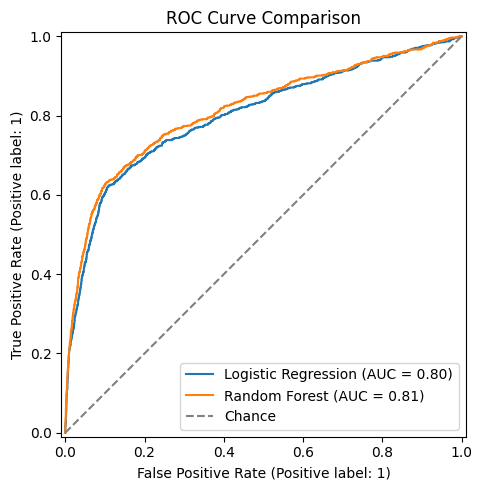

In [16]:

from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, logreg_preds), display_labels=['no', 'yes']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_preds), display_labels=['no', 'yes']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, logreg_proba, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()


### Feature importance (Random Forest) & coefficients (Logistic Regression)

This is the part that turns the model into a **business answer**: which factors most influence whether a client subscribes, so the bank knows who to prioritize contacting.

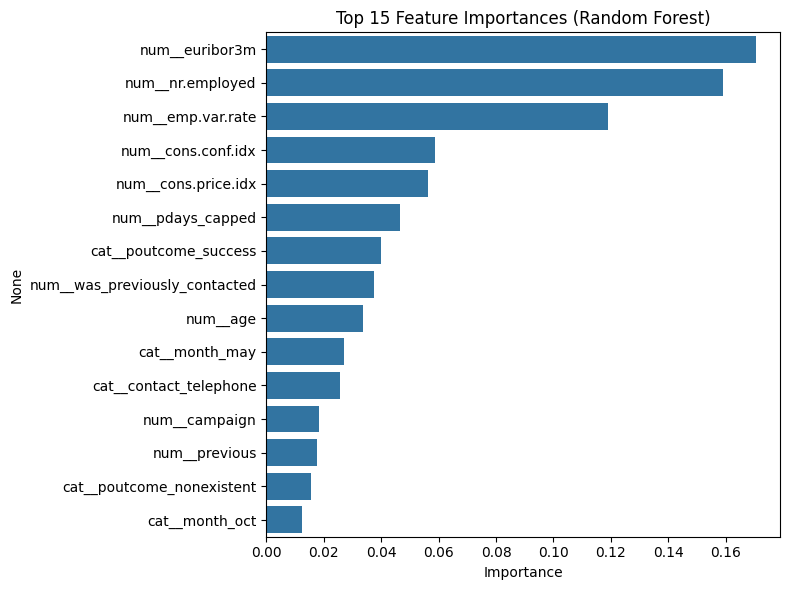

In [17]:

feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


/tmp/ipykernel_559/1806964717.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs.values, y=top_coefs.index, palette=colors)


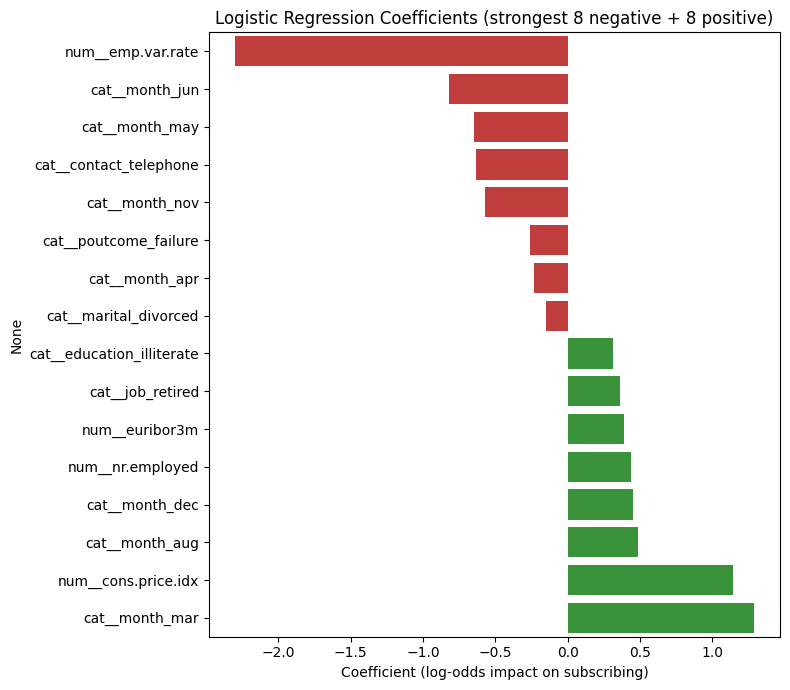

In [18]:

logreg_coefs = pd.Series(
    logreg_pipe.named_steps['model'].coef_[0], index=feature_names
).sort_values()

top_coefs = pd.concat([logreg_coefs.head(8), logreg_coefs.tail(8)])

plt.figure(figsize=(8, 7))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in top_coefs.values]
sns.barplot(x=top_coefs.values, y=top_coefs.index, palette=colors)
plt.title('Logistic Regression Coefficients (strongest 8 negative + 8 positive)')
plt.xlabel('Coefficient (log-odds impact on subscribing)')
plt.tight_layout()
plt.show()



## Conclusion

In this analysis, we explored the structure and composition of the bank marketing dataset. Key takeaways include:

- The dataset includes customer demographics and contact details, which can be useful for segmentation.
- A majority of customers do not subscribe to term deposits, indicating an imbalanced dataset.
- Further preprocessing, feature engineering, and modeling would be the next steps for predictive analysis.

This initial inspection sets the foundation for a deeper analysis or machine learning workflow to improve marketing effectiveness.
